In [263]:
import numpy as np
import tensorflow as tf
from tensorflow import keras
import matplotlib.pyplot as plt
from sklearn.feature_extraction.text import TfidfVectorizer
import import_ipynb
from MLPClass import Layer, MLP, Conv
import tensorflow_hub as hub
from tensorflow.keras.preprocessing import image
import os

In [264]:
def preprocess_image(img):
    img = np.array(img,dtype=np.float32)
    if img.max() > 1: # normalize
        img = img / 255.0
    if len(img.shape) == 1:
        if img.shape[0] == 784:
            img = img.reshape(28,28,1)
    if len(img.shape) == 2:
        img = img.reshape(img.shape[0],img.shape[1], 1)
    return img
    
def preprocess_text(text,vectorizer):
    return vectorizer.transform([text]).toarray()

def interpolate(baseline, input, alphas):
    return baseline + alphas[:, None] * (input - baseline)

def compute_gradients(model,images,target_class_idx):
    with tf.GradientTape() as tape:
        tape.watch(images)
        preds = model(images)
        probs = tf.nn.softmax(preds, axis=-1)[:,target_class_idx]
    return tape.gradient(probs, images)

def integrated_gradients_image(model,image,target_class_idx,m_steps=50):
    baseline = tf.zeros_like(image)
    alphas = tf.linspace(0.0, 1.0, m_steps + 1)
    interpolated = interpolate_images(baseline,image,alphas)
    grads = compute_gradients(model,interpolated,target_class_idx)
    avg_grads = (grads[:-1] + grads[1:]) / 2.0
    avg_grads = tf.reduce_mean(avg_grads,axis=0)
    return (image - baseline) * avg_grads

def integrated_gradients_text(model,vector,target_class_idx,m_steps=50):
    baseline = tf.zeros_like(vector)
    alphas = tf.linspace(0.0,1.0,m_steps + 1)
    interpolated = baseline + alphas[:, None] * (vector - baseline)
    with tf.GradientTape() as tape:
        tape.watch(interpolated)
        preds = model(interpolated)
        probs = tf.nn.softmax(preds, axis=-1)[:,target_class_idx]
    grads = tape.gradient(probs, interpolated)
    avg_grads = (grads[:-1] + grads[1:]) / 2.0
    avg_grads = tf.reduce_mean(avg_grads,axis=0)
    return (vector - baseline) * avg_grads

In [266]:
def load_images_from_folder(folder,label):
    data = []
    labels = []
    for file in os.listdir(folder):
        if file.endswith(".jpg") or file.endswith(".png"):
            path = os.path.join(folder, file)
            img = image.load_img(path, target_size=(64,64))
            img = image.img_to_array(img) / 255.0

            data.append(img)
            labels.append(label)
    return data, labels

cat_data, cat_labels = load_images_from_folder("/Users/graceg/Desktop/cats",0)
dog_data, dog_labels = load_images_from_folder("/Users/graceg/Desktop/dogs",1)
#cat_data = load_images_from_folder("/Users/graceg/Desktop/cats",0)

X_images = np.array(cat_data + dog_data)
y_images = np.array(cat_labels + dog_labels)

print("Dataset shape:", X_images.shape)
print(len(dog_data))
print(dog_labels)
print(y_images)
print(cat_data)

Dataset shape: (1, 64, 64, 3)
0
[]
[0]
[array([[[0.36862746, 0.36862746, 0.36078432],
        [0.21960784, 0.25882354, 0.25490198],
        [0.09411765, 0.15686275, 0.15686275],
        ...,
        [0.3647059 , 0.36078432, 0.3529412 ],
        [0.34901962, 0.3529412 , 0.32941177],
        [0.3647059 , 0.36078432, 0.34117648]],

       [[0.45490196, 0.4       , 0.3882353 ],
        [0.27058825, 0.2901961 , 0.27450982],
        [0.06666667, 0.12156863, 0.12156863],
        ...,
        [0.27450982, 0.2901961 , 0.29411766],
        [0.27450982, 0.28235295, 0.2784314 ],
        [0.24313726, 0.2784314 , 0.27450982]],

       [[0.48235294, 0.41960785, 0.36078432],
        [0.29803923, 0.3019608 , 0.28235295],
        [0.06666667, 0.12941177, 0.12941177],
        ...,
        [0.23529412, 0.26666668, 0.2784314 ],
        [0.25490198, 0.27450982, 0.29803923],
        [0.27058825, 0.28235295, 0.3019608 ]],

       ...,

       [[0.49019608, 0.7411765 , 0.6039216 ],
        [0.30980393, 0.56862

In [267]:
texts = [
    "I love texting",
    "This is ugly",
    "Amazing experience",
    "Worst food ever",
    "Television makes me happy",
    "I like to draw",
    "Sushi is disgusting"
]
labels = [1,0,1,0,1,1,0]

text_vectorizer = TfidfVectorizer()
X_text = text_vectorizer.fit_transform(texts).toarray()
y_text = np.array(labels)

# TRAIN

text_layers = [
    Layer(input_shape=(X_text.shape[1],),neurons=8,activation="relu"),
    Layer(neurons=2, activation="softmax")
]

text_model = MLP(
    model_input=X_text,
    model_output=y_text,
    layers=text_layers
)

text_model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

text_model.fit(X_text,y_text,epochs=10)

<Sequential name=sequential_86, built=False>
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 203ms/step - accuracy: 0.5714 - loss: 0.6595
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.5714 - loss: 0.6570
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.5714 - loss: 0.6544
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.5714 - loss: 0.6519
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.5714 - loss: 0.6493
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.5714 - loss: 0.6468
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.5714 - loss: 0.6443
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.5714 - loss: 0.6417
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.5714 - loss: 0.6392
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.5714 - loss: 0.6367


In [268]:
models = {
    "image_path": image_model,
    "image_numpy": image_model,
    "text": text_model
}

In [269]:
def show_image_with_ig(image,ig,title="IG"):
    image = tf.squeeze(image).numpy()
    ig = tf.squeeze(ig).numpy()
    
    if len(image.shape) == 1 and image.shape[0] == 784:
        image = image.reshape(28,28)
        ig = ig.reshape(28,28)

    if len(ig.shape) == 3: # heatmap
        heatmap = np.sum(np.abs(ig),axis=-1)
    else:
        heatmap = np.abs(ig)
    heatmap = (heatmap - heatmap.min()) / (heatmap.max() - heatmap.min() + 1e-8)

    plt.figure()
    plt.imshow(heatmap,cmap="inferno")
    plt.title("IG Heatmap")
    plt.axis("off")
    plt.show()

    plt.figure()
    plt.imshow(image,cmap='gray' if len(image.shape)==2 else None)
    plt.imshow(heatmap,cmap='jet',alpha=0.5)
    plt.title(title)
    plt.axis("off")
    plt.show()

In [270]:
def detect_type(input_data):
    if isinstance(input_data, str) and os.path.exists(input_data):
        return "image_path"
    if isinstance(input_data, str):
        return "text"
    if isinstance(input_data, np.ndarray):
        return "image_numpy"
    raise ValueError("Sorry! This is an unsupported input type.")

In [271]:
def predict_input(input_data):
    print("\nPREDICT")
    if isinstance(input_data,str) and os.path.exists(input_data):
        print("NOTE: IMAGE PATH DETECTED")
        img = image.load_img(input_data, target_size=(64,64))
        img_array = image.img_to_array(img) / 255.0
        preds = image_model.predict(np.expand_dims(img_array,0))
        pred_idx = np.argmax(preds)
        print("Predicted class:",pred_idx)
        ig = integrated_gradients_image(
            image_model,
            tf.convert_to_tensor(img_array,dtype=tf.float32),
            pred_idx
        )
        show_image_with_ig(img_array,ig)

    elif isinstance(input_data,np.ndarray):
        print("NUMPY IMAGE DETECTED")
        img_array = input_data
        preds = image_model.predict(np.expand_dims(img_array, 0))
        pred_idx = np.argmax(preds)
        print("Predicted class:",pred_idx)
        ig = integrated_gradients_image(
            image_model,
            tf.convert_to_tensor(img_array,dtype=tf.float32),
            pred_idx
        )
        show_image_with_ig(img_array,ig)

    elif isinstance(input_data,str):
        print("NOTE: TEXT DETECTED")
        X = text_vectorizer.transform([input_data]).toarray()
        preds = text_model.predict(X)
        pred_idx = np.argmax(preds)
        print("Prediction:",pred_idx)
        ig = integrated_gradients_text(
            text_model.model,
            tf.convert_to_tensor(X[0],dtype=tf.float32),
            pred_idx
        )
        print("Feature importance IG:")
        print(ig.numpy())
    else:
        print("Sorry! This is an unsupported input type.")


PREDICT
NOTE: TEXT DETECTED
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step
Prediction: 0
Feature importance IG:
[-0.  0. -0. -0. -0. -0. -0.  0. -0. -0.  0. -0.  0.  0. -0.  0. -0.  0.
  0.]

PREDICT
NUMPY IMAGE DETECTED
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step
Predicted class: 1


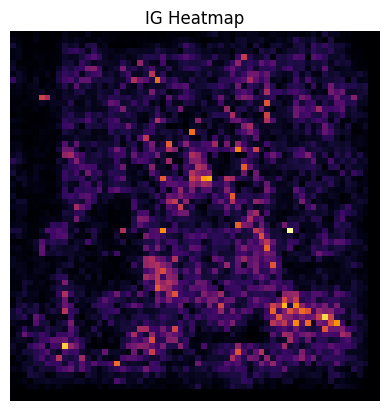

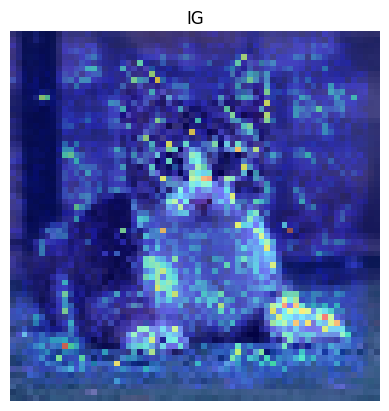


PREDICT
NOTE: TEXT DETECTED
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step
Prediction: 1
Feature importance IG:
[ 0.         -0.          0.          0.          0.         -0.
  0.         -0.          0.          0.05085681 -0.         -0.
  0.         -0.         -0.          0.00546227  0.         -0.
  0.        ]


In [272]:
predict_input("/Users/graceg/Desktop/cat1.jpg")
predict_input(X_images[0])
predict_input("I love this")